<a href="https://colab.research.google.com/github/Pratik0076/AI-Symptoms-Analysis/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Saving twitter_training.csv to twitter_training (1).csv
Loaded: twitter_training (1).csv
Cleaning text...
Done cleaning!

Sentiment distribution (after filtering):
Sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64

Training Logistic Regression ...
F1-score (weighted): 0.6456
              precision    recall  f1-score   support

  Irrelevant       0.61      0.46      0.53      2575
    Negative       0.66      0.77      0.71      4472
     Neutral       0.65      0.59      0.62      3622
    Positive       0.66      0.69      0.67      4131

    accuracy                           0.65     14800
   macro avg       0.64      0.63      0.63     14800
weighted avg       0.65      0.65      0.65     14800



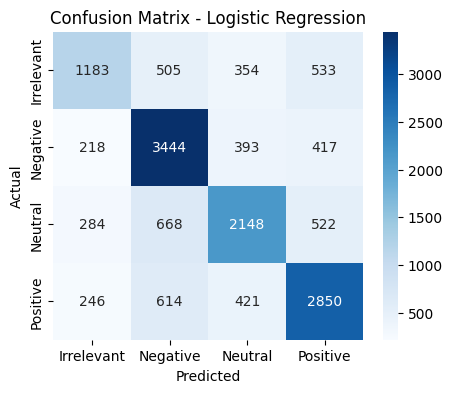


Training Naive Bayes ...
F1-score (weighted): 0.5888
              precision    recall  f1-score   support

  Irrelevant       0.66      0.28      0.39      2575
    Negative       0.59      0.79      0.68      4472
     Neutral       0.62      0.50      0.56      3622
    Positive       0.59      0.70      0.64      4131

    accuracy                           0.61     14800
   macro avg       0.62      0.57      0.57     14800
weighted avg       0.61      0.61      0.59     14800



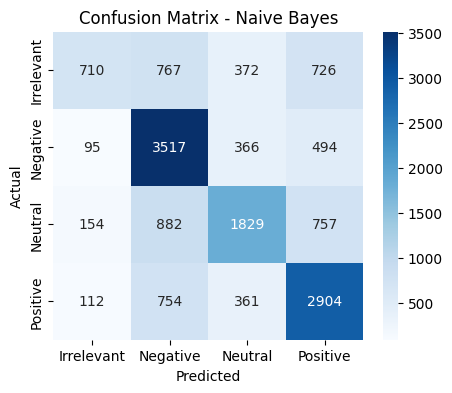


Training SVM ...
F1-score (weighted): 0.6615
              precision    recall  f1-score   support

  Irrelevant       0.61      0.49      0.55      2575
    Negative       0.70      0.76      0.73      4472
     Neutral       0.68      0.60      0.64      3622
    Positive       0.64      0.73      0.68      4131

    accuracy                           0.67     14800
   macro avg       0.66      0.64      0.65     14800
weighted avg       0.66      0.67      0.66     14800



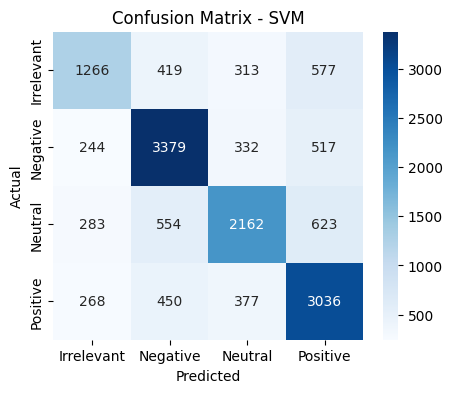

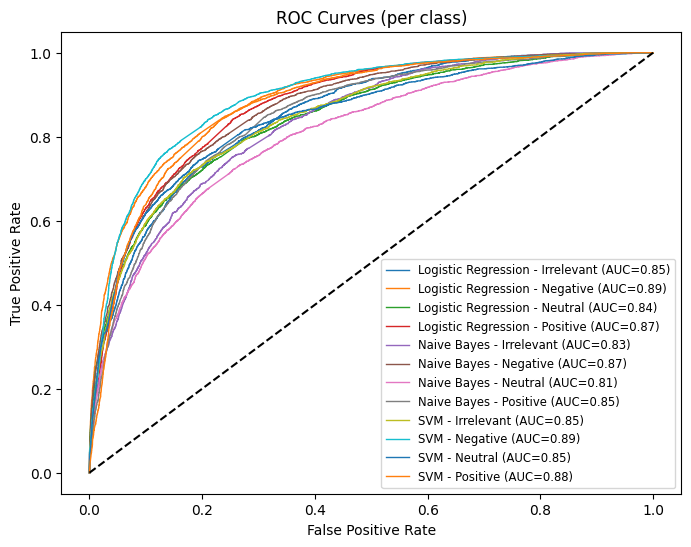


✅ Analysis complete! Models trained and plots displayed.


In [1]:
# ====================== SETUP ======================
!pip install nltk scikit-learn matplotlib seaborn joblib

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ✅ Download required NLTK resources (includes punkt_tab)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

# ====================== UPLOAD CSV ======================
from google.colab import files
uploaded = files.upload()

# Replace the filename below with your uploaded CSV name
csv_file = list(uploaded.keys())[0]
print("Loaded:", csv_file)

# ====================== LOAD AND CLEAN ======================
df = pd.read_csv(csv_file, header=None)
df = df.iloc[:, :4]
df.columns = ['ID', 'Entity', 'Sentiment', 'Content']
df.dropna(subset=['Content','Sentiment'], inplace=True)

def clean_text(s):
    s = str(s)
    s = re.sub(r'http\S+|www\S+|https\S+', '', s)
    s = re.sub(r'\@\w+|\#', '', s)
    s = re.sub(r'[^A-Za-z0-9\s]', ' ', s)
    s = s.lower()
    tokens = nltk.word_tokenize(s)
    stops = set(stopwords.words('english'))
    lem = WordNetLemmatizer()
    tokens = [lem.lemmatize(t) for t in tokens if t not in stops and len(t) > 1]
    return " ".join(tokens)

print("Cleaning text...")
df['Clean'] = df['Content'].apply(clean_text)
print("Done cleaning!")

# Filter out sentiment categories with two or fewer entries
sentiment_counts = df['Sentiment'].value_counts()
sentiments_to_keep = sentiment_counts[sentiment_counts > 2].index
df = df[df['Sentiment'].isin(sentiments_to_keep)]

print("\nSentiment distribution (after filtering):")
print(df['Sentiment'].value_counts())


# ====================== FEATURE EXTRACTION ======================
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
countv = CountVectorizer(max_features=3000, ngram_range=(1,2))

X_tfidf = tfidf.fit_transform(df['Clean'])
y = df['Sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# ====================== TRAIN MODELS ======================
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(kernel='linear', probability=True)
}

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
class_names = lb.classes_

roc_scores = {}

for name, model in models.items():
    print(f"\nTraining {name} ...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds, average='weighted', zero_division=0)
    print(f"F1-score (weighted): {f1:.4f}")
    print(classification_report(y_test, preds, zero_division=0))

    cm = confusion_matrix(y_test, preds, labels=class_names)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC curve data
    if hasattr(model, "predict_proba"):
        roc_scores[name] = model.predict_proba(X_test)
    else:
        try:
            y_score = model.decision_function(X_test)
            if y_score.ndim == 1:
                y_score = np.vstack([1-y_score, y_score]).T
            roc_scores[name] = y_score
        except:
            pass

# ====================== PLOT ROC CURVES ======================
plt.figure(figsize=(8,6))
for name, y_score in roc_scores.items():
    for i, cls in enumerate(class_names):
        try:
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=1, label=f'{name} - {cls} (AUC={roc_auc:.2f})')
        except:
            pass
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (per class)')
plt.legend(loc='lower right', fontsize='small')
plt.show()

print("\n✅ Analysis complete! Models trained and plots displayed.")